In [3]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import datetime
import sys
import pickle

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.stats import beta

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as pltP
import subprocess

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'


In [2]:
df_gfp = pd.read_csv("data/gfp/gfp_dataset_10mut.csv")
df_nmt = pd.read_csv("data/nmt/nmt_full_seq.csv")

In [11]:
si = np.where(df_nmt.columns == "1")[0][0]
ei = np.where(df_nmt.columns == "272")[0][0]+1


positions_with_mutations =  np.array([len(pd.unique(df_nmt.iloc[:,i])) > 1 for i in range(si,ei)])


new_df_nmt_columns = zip(df_nmt.columns[si:ei][positions_with_mutations],
                            df_nmt.iloc[0,si:ei][positions_with_mutations])

new_df_nmt_columns =["%s%s" % (b,a) for a,b in new_df_nmt_columns]     


new_df_nmt =\
    pd.concat([df_nmt["name"],
            df_nmt["seq"],
            df_nmt["activity"], 
            df_nmt["num_muts"],
            df_nmt["p1"],
            df_nmt["p2"],
            df_nmt.iloc[:,si:ei].iloc[:,positions_with_mutations]
            ], axis=1)
 
new_df_nmt.columns = ['name', 'seq', 'activity', 'num_muts', 'p1', 'p2'] + new_df_nmt_columns

In [16]:
new_df_nmt_si = np.where(new_df_nmt.columns == "Y20")[0][0]
new_df_nmt_ei = np.where(new_df_nmt.columns == "F253")[0][0] + 1

new_df_nmt_columns = new_df_nmt.columns[new_df_nmt_si:new_df_nmt_ei]
for c in new_df_nmt_columns:
    print(np.unique(new_df_nmt[c], return_counts=True))



(array(['F', 'H', 'Y'], dtype=object), array([  9,   4, 225]))
(array(['F', 'Y'], dtype=object), array([  7, 231]))
(array(['A', 'D', 'E', 'N', 'S', 'T'], dtype=object), array([ 15,   3, 201,   5,   6,   8]))
(array(['F', 'I', 'M', 'V', 'W', 'Y'], dtype=object), array([  8,  53,   1,  10, 163,   3]))
(array(['C', 'D', 'E', 'H'], dtype=object), array([ 14,   7,   1, 216]))
(array(['F', 'H', 'Y'], dtype=object), array([160,   4,  74]))
(array(['D', 'G'], dtype=object), array([231,   7]))
(array(['A', 'C', 'D', 'F', 'L', 'M', 'S', 'T', 'V', 'Y'], dtype=object), array([ 47,  13,   1,   8,   8, 103,   5,  27,  16,  10]))
(array(['L', 'M'], dtype=object), array([234,   4]))
(array(['A', 'C', 'E', 'M', 'N', 'Q', 'R', 'S', 'T'], dtype=object), array([  9, 199,   3,   1,   3,   8,   5,   7,   3]))
(array(['F', 'Y'], dtype=object), array([  1, 237]))
(array(['A', 'C', 'G', 'H', 'M', 'N', 'S', 'T', 'V'], dtype=object), array([ 37,  21,   1,  15,   1,  10, 128,  14,  11]))
(array(['F', 'H', 'L', '

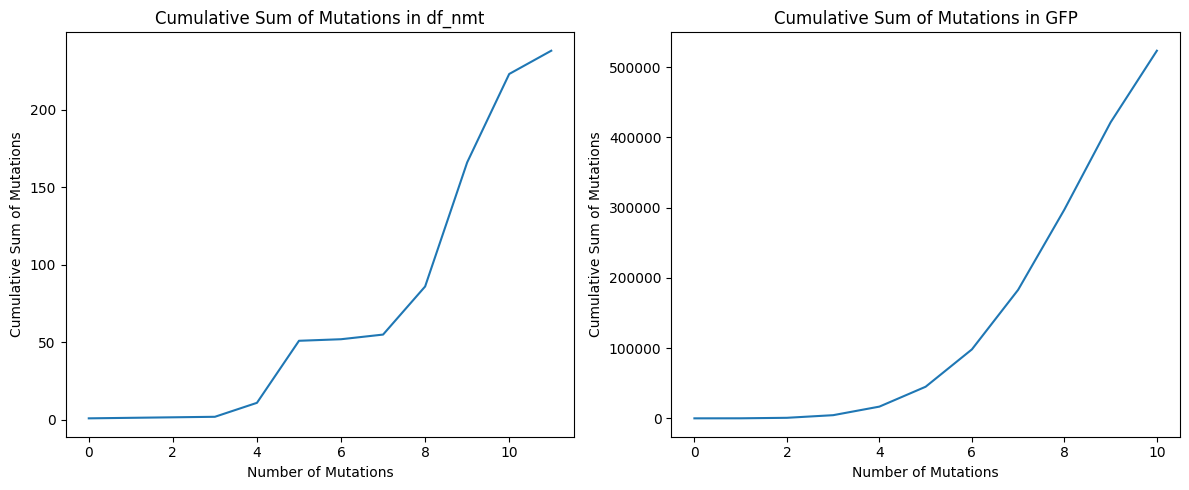

In [ ]:
nmuts_nmt =  df_nmt["num_muts"]
nmuts_gfp =  df_gfp["num_muts"]

counts_nmt = np.unique(nmuts_nmt, return_counts=True)
counts_gfp = np.unique(nmuts_gfp, return_counts=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(counts_nmt[0], counts_nmt[1].cumsum())
axs[0].set_xlabel("Number of Mutations")
axs[0].set_ylabel("Cumulative Sum of Mutations")
axs[0].set_title("Cumulative Sum of Mutations in df_nmt")

axs[1].plot(counts_gfp[0], counts_gfp[1].cumsum())
axs[1].set_xlabel("Number of Mutations")
axs[1].set_ylabel("Cumulative Sum of Mutations")
axs[1].set_title("Cumulative Sum of Mutations in GFP")

plt.tight_layout()
plt.show()

In [5]:
[np.floor(counts_nmt[1].cumsum()[counts_nmt[0] == nm].item()) for nm in [5, 6, 7, 8, 9]]

#[np.floor(counts_gfp[1].cumsum()[counts_gfp[0] == nm].item()) for nm in [3, 4, 5, 6]]



[51.0, 52.0, 55.0, 86.0, 166.0]

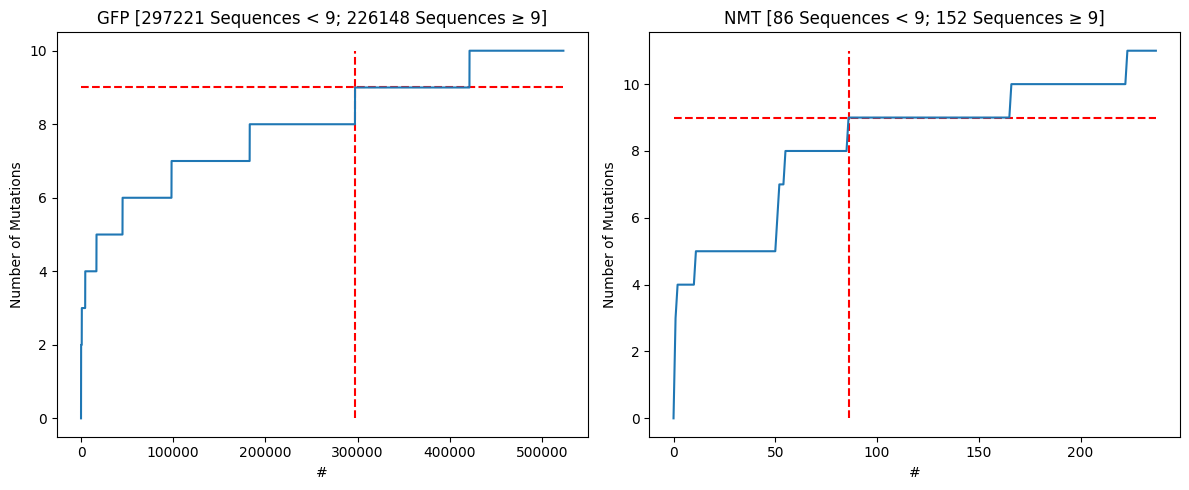

In [6]:
indices_sorted_by_nmut_nmt = np.argsort(np.array(nmuts_nmt.tolist()))
indices_sorted_by_nmut_gfp = np.argsort(np.array(nmuts_gfp.tolist()))

nmuts_sorted_gfp = nmuts_gfp[indices_sorted_by_nmut_gfp]
nmuts_sorted_nmt = nmuts_nmt[indices_sorted_by_nmut_nmt]


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# GFP plot with horizontal line and annotation at n=9 as in NMT
index_of_first_9_gfp = np.where(nmuts_sorted_gfp == 9)[0]
if len(index_of_first_9_gfp) > 0:
    index_of_first_9_gfp = index_of_first_9_gfp[0]
    axs[0].hlines(y=9, xmin=0, xmax=len(nmuts_sorted_gfp)-1, colors='r', linestyles='dashed')
    axs[0].vlines(x=index_of_first_9_gfp, ymin=0, ymax=max(nmuts_sorted_gfp), colors='r', linestyles='dashed')
    title_gfp = "GFP [%d Sequences < 9; %d Sequences ≥ 9]" % (
        index_of_first_9_gfp, len(nmuts_sorted_gfp) - index_of_first_9_gfp)
else:
    title_gfp = "GFP (No sequences with exactly 9 mutations)"

axs[0].plot(range(len(nmuts_sorted_gfp)), nmuts_sorted_gfp)
axs[0].set_xlabel("#")
axs[0].set_ylabel("Number of Mutations")
axs[0].set_title(title_gfp)

# NMT plot (unchanged)
index_of_first_9_nmt = np.where(nmuts_sorted_nmt == 9)[0]
if len(index_of_first_9_nmt) > 0:
    index_of_first_9_nmt = index_of_first_9_nmt[0]
    axs[1].hlines(y=9, xmin=0, xmax=len(nmuts_sorted_nmt)-1, colors='r', linestyles='dashed')
    axs[1].vlines(x=index_of_first_9_nmt, ymin=0, ymax=max(nmuts_sorted_nmt), colors='r', linestyles='dashed')
    title_nmt = "NMT [%d Sequences < 9; %d Sequences ≥ 9]" % (
        index_of_first_9_nmt, len(nmuts_sorted_nmt) - index_of_first_9_nmt)
else:
    title_nmt = "NMT (No sequences with exactly 9 mutations)"

axs[1].plot(range(len(nmuts_sorted_nmt)), nmuts_sorted_nmt)
axs[1].set_xlabel("#")
axs[1].set_ylabel("Number of Mutations")
axs[1].set_title(title_nmt)

plt.tight_layout()
plt.show()



In [ ]:
N_iterations = 30

print([np.floor(counts_nmt[1].cumsum()[counts_nmt[0] == nm].item()) for nm in [5, 6, 7, 8, 9]])

budget_size = [5, 10, 20, 30, 40, 50]
max_mutation_to_build_sample = [8, 9, 10]
min_mutation = 5


all_sets = {}

for max_mutation in max_mutation_to_build_sample:

    split = {}

    held_out_index = np.where(nmuts_sorted_nmt == max_mutation + 1)[0][0]
    held_out_set = nmuts_sorted_nmt[held_out_index:].to_numpy()
    held_out_set_indices = indices_sorted_by_nmut_nmt[held_out_index:]

    mutations_in_budget = range(min_mutation, max_mutation + 1)

    split["held_out_indices"] = held_out_set_indices
    split["sampled_by_budget_and_complexity"] = {}

    for mutation in mutations_in_budget:

        max_train_index = (np.where(nmuts_sorted_nmt == mutation)[0][-1] + 1)
        train_set = nmuts_sorted_nmt[:max_train_index].to_numpy()
        train_set_indices = indices_sorted_by_nmut_nmt[:max_train_index]
        sample_indices = [[np.random.choice(range(len(train_set_indices)), size=budget, replace=False) for i in range(N_iterations)] for budget in budget_size]

        sample_for_mutation = {}
        for idx, budget in enumerate(budget_size):
            sample_for_mutation["budget_%d" % budget] = [train_set_indices[indices] for indices in sample_indices[idx]]

        split["sampled_by_budget_and_complexity"]["up_to_%d" % mutation] = sample_for_mutation    
    
    all_sets["held_out_%d" % (max_mutation + 1)] = split




[51.0, 52.0, 55.0, 86.0, 166.0]


In [ ]:
### SANITY CHECK

for held_out_key in all_sets.keys():
    print("SANITY CHECK: ", held_out_key)
    held_out_indices =all_sets[held_out_key]["held_out_indices"]
    sampled_by_budget_and_complexity = all_sets[held_out_key]["sampled_by_budget_and_complexity"]
    all_sampling_regimes = list(sampled_by_budget_and_complexity.keys())
    all_budgets = list(sampled_by_budget_and_complexity[all_sampling_regimes[0]].keys())


    overall_in_held_out_indices = \
        [np.isin(sampled_by_budget_and_complexity[sampling_regime][budget][i], held_out_indices).sum() 
                    for sampling_regime in all_sampling_regimes 
                        for budget in all_budgets 
                            for i in range(N_iterations)]

    assert(sum(overall_in_held_out_indices) == 0)
    print("SANITY CHECK PASSED")


os.getcwd()
pickle.dump(all_sets, open("./data/nmt/sampling_indices/all_sets_up_to_11.pkl", "wb"))
    

SANITY CHECK:  held_out_9
SANITY CHECK PASSED
SANITY CHECK:  held_out_10
SANITY CHECK PASSED
SANITY CHECK:  held_out_11
SANITY CHECK PASSED


In [9]:

for mdn in ["progen2-medium"]:#["esm_150m", "one_hot", "prot_bert", "progen2-small", "esm_8m", "esm_35m", "esm_650m"]:

    cmd = f"python train_regressors_over_embedding_fixed_budget.py --model_name {mdn} --indices_pickle_file ./data/nmt/sampling_indices/all_sets_up_to_11.pkl"
    print(cmd)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")

python train_regressors_over_embedding_fixed_budget.py --model_name progen2-medium --indices_pickle_file ./data/nmt/sampling_indices/all_sets_up_to_11.pkl
Submitting job  via:  bsub -n 6 -R rusage[mem=64GB] -R span[ptile=6] -e /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260125_191527/job_outputs/err_file_worker_26498202 -o /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260125_191527/job_outputs/out_file_worker_26498202 -q short /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260125_191527/job_worker_26498202.sh
Job submitted successfully. Output: Job <912681> is submitted to queue <short>.



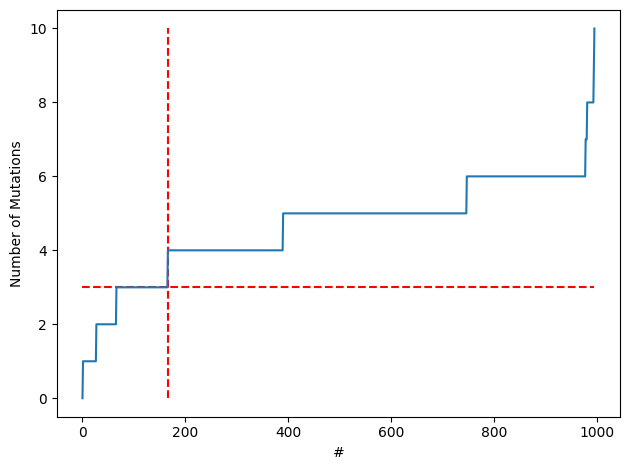

In [17]:
gcn4_dataset = pd.read_csv("data/gcn4/gcn4.csv")
nmuts_gcn4 = gcn4_dataset["num_muts"]
indices_sorted_by_nmut_gcn4 = np.argsort(np.array(nmuts_gcn4.tolist()))

nmuts_sorted_gcn4 = nmuts_gcn4[indices_sorted_by_nmut_gcn4]

# gcn4 plot (unchanged)
index_of_first_3_gcn4 = np.where(nmuts_sorted_gcn4 == 4)[0]
if len(index_of_first_3_gcn4) > 0:
    index_of_first_3_gcn4 = index_of_first_3_gcn4[0]
    plt.hlines(y=3, xmin=0, xmax=len(nmuts_sorted_gcn4)-1, colors='r', linestyles='dashed')
    plt.vlines(x=index_of_first_3_gcn4, ymin=0, ymax=max(nmuts_sorted_gcn4), colors='r', linestyles='dashed')
    title_gcn4 = "gcn4 [%d Sequences < 3; %d Sequences ≥ 3]" % (
        index_of_first_3_gcn4, len(nmuts_sorted_gcn4) - index_of_first_3_gcn4)
else:
    title_gcn4 = "gcn4 (No sequences with exactly 3 mutations)"

plt.plot(range(len(nmuts_sorted_gcn4)), nmuts_sorted_gcn4)
plt.xlabel("#")
plt.ylabel("Number of Mutations")


plt.tight_layout()
plt.show()



In [46]:
print(np.where(nmuts_sorted_gcn4 == 7)[0][0])
print(np.where(nmuts_sorted_gcn4 == 3)[0][0])

978
66


In [47]:
N_iterations = 30

budget_size = [5, 10, 20, 30, 40, 50]
max_mutation_to_build_sample = [5, 6, 7]
min_mutation = 3
os.makedirs("./data/gcn4/sampling_indices", exist_ok=True)

all_sets = {}

for max_mutation in max_mutation_to_build_sample:

    split = {}

    held_out_index = np.where(nmuts_sorted_gcn4 == max_mutation + 1)[0][0]
    held_out_set = nmuts_sorted_gcn4[held_out_index:].to_numpy()
    held_out_set_indices = indices_sorted_by_nmut_gcn4[held_out_index:]

    mutations_in_budget = range(min_mutation, max_mutation + 1)

    split["held_out_indices"] = held_out_set_indices
    split["sampled_by_budget_and_complexity"] = {}

    for mutation in mutations_in_budget:

        max_train_index = (np.where(nmuts_sorted_gcn4 == mutation)[0][-1] + 1)
        train_set = nmuts_sorted_gcn4[:max_train_index].to_numpy()
        train_set_indices = indices_sorted_by_nmut_gcn4[:max_train_index]
        sample_indices = [[np.random.choice(range(len(train_set_indices)), size=budget, replace=False) for i in range(N_iterations)] for budget in budget_size]

        sample_for_mutation = {}
        for idx, budget in enumerate(budget_size):
            sample_for_mutation["budget_%d" % budget] = [train_set_indices[indices] for indices in sample_indices[idx]]

        split["sampled_by_budget_and_complexity"]["up_to_%d" % mutation] = sample_for_mutation    
    
    all_sets["held_out_%d" % (max_mutation + 1)] = split

    ### SANITY CHECK

for held_out_key in all_sets.keys():
    print("SANITY CHECK: ", held_out_key)
    held_out_indices =all_sets[held_out_key]["held_out_indices"]
    sampled_by_budget_and_complexity = all_sets[held_out_key]["sampled_by_budget_and_complexity"]
    all_sampling_regimes = list(sampled_by_budget_and_complexity.keys())
    all_budgets = list(sampled_by_budget_and_complexity[all_sampling_regimes[0]].keys())


    overall_in_held_out_indices = \
        [np.isin(sampled_by_budget_and_complexity[sampling_regime][budget][i], held_out_indices).sum() 
                    for sampling_regime in all_sampling_regimes 
                        for budget in all_budgets 
                            for i in range(N_iterations)]

    assert(sum(overall_in_held_out_indices) == 0)
    print("SANITY CHECK PASSED")


os.getcwd()

pickle.dump(all_sets, open("./data/gcn4/sampling_indices/all_sets_up_to_8.pkl", "wb"))
    




SANITY CHECK:  held_out_6
SANITY CHECK PASSED
SANITY CHECK:  held_out_7
SANITY CHECK PASSED
SANITY CHECK:  held_out_8
SANITY CHECK PASSED


In [3]:


gcn4_dataset_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pte/pte.csv"
embeddings_base_folder = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pte/embeddings"

gcn4_df = None
try:
    import pandas as pd
    gcn4_df = pd.read_csv(gcn4_dataset_path)
    n_total = len(gcn4_df)
except Exception:
    raise RuntimeError("Could not load lov dataset for index/length.")

for model_name in os.listdir(embeddings_base_folder):
    model_folder = os.path.join(embeddings_base_folder, model_name)
    if not os.path.isdir(model_folder):
        continue

    embeddings_files = [f for f in os.listdir(model_folder) if f.startswith("embeddings_of_nmut_")]
    if not embeddings_files:
        continue

    all_indices = torch.full((n_total,), -1, dtype=torch.long)
    embedding_sample = torch.load(os.path.join(model_folder, embeddings_files[0]))
    emb_shape = embedding_sample.shape[1:]
    embeddings = torch.zeros((n_total, *emb_shape), dtype=embedding_sample.dtype)
    y_values = torch.zeros((n_total,), dtype=torch.float)
    filled = torch.zeros((n_total,), dtype=torch.bool)

    for nmut in range(0,11):
        ind_path = os.path.join(model_folder, f"indices_of_nmut_{nmut}.pt")
        emb_path = os.path.join(model_folder, f"embeddings_of_nmut_{nmut}.pt")
        yval_path = os.path.join(model_folder, f"y_values_of_nmut_{nmut}.pt")
        if not (os.path.exists(ind_path) and os.path.exists(emb_path) and os.path.exists(yval_path)):
            continue

        indices = torch.load(ind_path)
        embs = torch.load(emb_path)
        ys = torch.load(yval_path)
        embeddings[indices] = embs
        y_values[indices] = ys
        filled[indices] = True
        all_indices[indices] = indices

    if not filled.all():
        raise ValueError(f"Not all rows filled for {model_name}: {(~filled).sum().item()} missing")
    # Assert that y_values is equal to gcn4_df["activity"]
    # we'll use np.allclose to allow for dtype/float rounding variations if any
    y_values_gcn4 = torch.tensor(gcn4_df["activity"].values, dtype=y_values.dtype)
    assert torch.allclose(y_values, y_values_gcn4), "y_values do not match gcn4 dataset activity column"
    torch.save(embeddings, os.path.join(model_folder, "embeddings.pt"))
    torch.save(y_values, os.path.join(model_folder, "y_values.pt"))
    torch.save(torch.arange(n_total), os.path.join(model_folder, "indices.pt"))


/tmp/ipykernel_149182/4069677003.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embedding_sample = torch.load(os.path.join(model_folder, embeddings_files[0]))
/tmp/ipy

In [ ]:

for mdn in ["esm_3b","esm_8m" "esm_150m", "prot_bert", "progen2-small", "esm_35m", "esm_650m",  "progen2-medium"]:

    cmd = f"python train_regressors_over_embedding_fixed_budget.py --model_name {mdn} --indices_pickle_file ./data/gcn4/sampling_indices/all_sets_up_to_8.pkl --dataset gcn4"
    print(cmd)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")

python train_regressors_over_embedding_fixed_budget.py --model_name esm_3b --indices_pickle_file ./data/gcn4/sampling_indices/all_sets_up_to_8.pkl --dataset gcn4
Submitting job  via:  bsub -n 6 -R rusage[mem=64GB] -R span[ptile=6] -e /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260203_175318/job_outputs/err_file_worker_42572663 -o /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260203_175318/job_outputs/out_file_worker_42572663 -q short /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/tmp_files/collect_all_job_results_20260203_175318/job_worker_42572663.sh
Job submitted successfully. Output: Job <636480> is submitted to queue <short>.



In [10]:
def generate_beta_regimes(training_set_size, ab_range=range(1,2)):
    x = np.linspace(0, 1, training_set_size + 1, endpoint=False)[1:]
    regimes = []

    for a in ab_range:
        for b in ab_range:

            #if a % 2 == 0 and b % 2 == 0 and (a != b):
            beta_pdf = beta.pdf(x, a, b)
            probabilities = np.array(beta_pdf / beta_pdf.sum())
            regimes.append(probabilities)
        
    return x, regimes



In [11]:

held_out_index = np.where(nmuts_sorted_nmt == 10)[0][0]
held_out_set = nmuts_sorted_nmt[held_out_index:].to_numpy()
held_out_set_indices = indices_sorted_by_nmut_nmt[held_out_index:]

training_set = nmuts_sorted_nmt[:held_out_index].to_numpy()
training_set_indices = indices_sorted_by_nmut_nmt[:held_out_index]


x, probability_sampling_regimes = generate_beta_regimes(len(training_set))

budget_size = [10, 25, 50, 100]
N_iterations = 100000


all_results = {}

for budget in budget_size:
    
    results = []

    for i in range(N_iterations):

        prob_regime_index = np.random.choice(range(len(probability_sampling_regimes)))
        random_probability_regime = probability_sampling_regimes[prob_regime_index]

        sample_indices = np.random.choice(
            range(len(training_set)),
            size=budget,
            replace=False,
            p=random_probability_regime
        )

        sample_nmt = training_set[sample_indices]

        results.append({"Average mutations": np.mean(sample_nmt), 
                        "Mutations std": np.std(sample_nmt), 
                        "Mutations": np.array(sample_nmt.tolist()), 
                        "Sample indices": sample_indices, 
                        "Training set indices": training_set_indices[sample_indices]})
    
    all_results[budget] = results



/tmp/ipykernel_2722829/1572106059.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


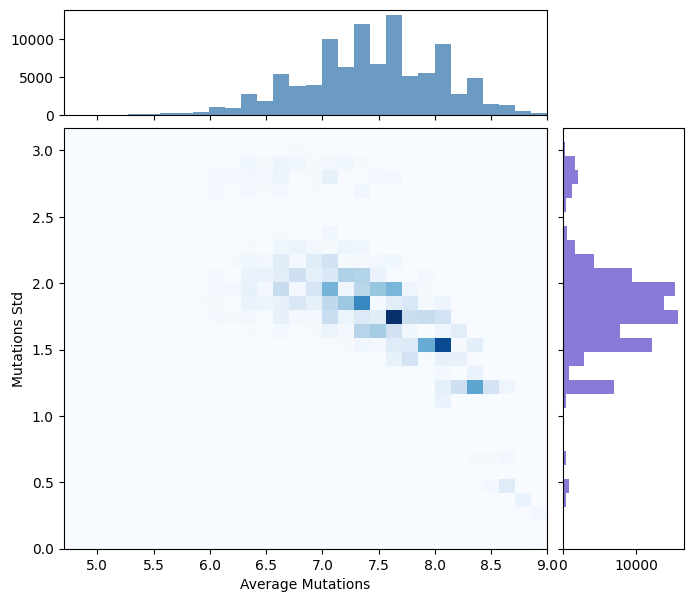

In [12]:
budget = 10

avg_mut = [i["Average mutations"] for i in all_results[budget]]
mut_std = [i["Mutations std"] for i in all_results[budget]]

#avg_mut = np.log2(np.round(np.array(avg_mut)))
#mut_std = np.log2(np.round(np.array(mut_std)))

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

ax_main = plt.subplot(gs[1, 0])
ax_xhist = plt.subplot(gs[0, 0], sharex=ax_main)
ax_yhist = plt.subplot(gs[1, 1], sharey=ax_main)

# 2D histogram
hist = ax_main.hist2d(avg_mut, mut_std, bins=30, cmap='Blues')
plt.setp(ax_xhist.get_xticklabels(), visible=False)
plt.setp(ax_yhist.get_yticklabels(), visible=False)

# Marginal for average mutations (top)
ax_xhist.hist(avg_mut, bins=30, color='steelblue', alpha=0.8)
#ax_xhist.set_ylabel("Freq.")
#ax_xhist.set_title("Marginal: Avg Mutations and Mut Std")

# Marginal for mutation std (right)
ax_yhist.hist(mut_std, bins=30, orientation='horizontal', color='slateblue', alpha=0.8)
#ax_yhist.set_xlabel("Freq.")

ax_main.set_xlabel("Average Mutations")
ax_main.set_ylabel("Mutations Std")
# ax_main.set_title("2D Histogram: Avg Mutations vs Mutations Std (budget=%d)" % budget)
# cbar = fig.colorbar(hist[3], ax=ax_main, fraction=0.047, pad=0.01)
# cbar.set_label('Counts')

ax_xhist.tick_params(axis="x", labelbottom=False)
ax_yhist.tick_params(axis="y", labelleft=False)

plt.tight_layout()
plt.show()



In [13]:
held_out_index = np.where(nmuts_sorted_gfp == 8)[0][0]
held_out_set = nmuts_sorted_gfp[held_out_index:].to_numpy()
held_out_set_indices = indices_sorted_by_nmut_gfp[held_out_index:]


training_set = nmuts_sorted_gfp[:held_out_index].to_numpy()
training_set_indices = indices_sorted_by_nmut_gfp[:held_out_index]

budget_size = [100, 1000, 5000, 10000]

N_iterations = 5000


all_results_gfp = {}

for budget in budget_size:

    results = []
    for i in range(N_iterations):
        sample_indices = np.random.choice(range(len(training_set)), size=budget, replace=False)
        sample_gfp = training_set[sample_indices]

        results.append({"Average mutations": np.mean(sample_gfp), 
                        "Mutations std": np.std(sample_gfp), 
                        "Mutations": np.array(sample_gfp.tolist()), 
                        "Sample indices": sample_indices, 
                        "Training set indices": training_set_indices[sample_indices]})
    
    all_results_gfp[budget] = results



In [14]:
training_set








# Example: Non-uniform sampling with replacement using numpy
# Suppose we want to sample from `training_set` with custom probabilities for each element

# Create a probability distribution shaped like the Beta PDF evaluated at equally spaced points between 0 and 1 (excluding endpoints).


a, b = 1, 6  # adjust as needed
  # avoid 0 since beta pdf is undefined at 0 for a<1
# If len(training_set) > 1, concatenate a very small value at the start to keep the same length
if len(training_set) > 1:
    x = np.concatenate(([1e-6], x))
else:
    x = np.array([0.5])  # fallback for single element

beta_pdf = beta.pdf(x, a, b)
probabilities = beta_pdf / beta_pdf.sum()

# Number of samples you want to draw
n_samples = 500  # pick any number

# Perform non-uniform sampling with replacement:

print(np.mean(non_uniform_samples))



plt.plot(x, beta_pdf)

NameError: name 'non_uniform_samples' is not defined

In [ ]:
plt.hist(non_uniform_samples)
print(np.mean(non_uniform_samples))
print(np.std(non_uniform_samples))

In [ ]:
budget = 1000

avg_mut = [i["Average mutations"] for i in all_results_gfp[budget]]
mut_std = [i["Mutations std"] for i in all_results_gfp[budget]]

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

ax_main = plt.subplot(gs[1, 0])
ax_xhist = plt.subplot(gs[0, 0], sharex=ax_main)
ax_yhist = plt.subplot(gs[1, 1], sharey=ax_main)

# 2D histogram
hist = ax_main.hist2d(avg_mut, mut_std, bins=30, cmap='Blues')
plt.setp(ax_xhist.get_xticklabels(), visible=False)
plt.setp(ax_yhist.get_yticklabels(), visible=False)

# Marginal for average mutations (top)
ax_xhist.hist(avg_mut, bins=30, color='steelblue', alpha=0.8)
#ax_xhist.set_ylabel("Freq.")
#ax_xhist.set_title("Marginal: Avg Mutations and Mut Std")

# Marginal for mutation std (right)
ax_yhist.hist(mut_std, bins=30, orientation='horizontal', color='slateblue', alpha=0.8)
#ax_yhist.set_xlabel("Freq.")

ax_main.set_xlabel("Average Mutations")
ax_main.set_ylabel("Mutations Std")
# ax_main.set_title("2D Histogram: Avg Mutations vs Mutations Std (budget=%d)" % budget)
# cbar = fig.colorbar(hist[3], ax=ax_main, fraction=0.047, pad=0.01)
# cbar.set_label('Counts')

ax_xhist.tick_params(axis="x", labelbottom=False)
ax_yhist.tick_params(axis="y", labelleft=False)

plt.tight_layout()
plt.show()



In [15]:
df_esm_8m = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_esm_8m")
df_esm_35m = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_esm_35m")
df_esm_150m = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_esm_150m")
df_esm_650m = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_esm_650m")
df_esm_3b = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_esm_3b")
df_one_hot = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_one_hot")
df_progen2_small = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_progen2-small")
df_progen2_medium = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_progen2-medium")
df_prot_bert = pd.read_csv("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/results/by_complexity_and_budget_up_to_11/mlp_llm_200_20_prot_bert")

df_esm_8m["model_name"] = "esm_8m"
df_esm_35m["model_name"] = "esm_35m"
df_esm_150m["model_name"] = "esm_150m"
df_esm_650m["model_name"] = "esm_650m"
df_esm_3b["model_name"] = "esm_3b"
df_one_hot["model_name"] = "one_hot"
df_progen2_small["model_name"] = "progen2-small"
df_progen2_medium["model_name"] = "progen2-medium"
df_prot_bert["model_name"] = "prot_bert"

df = pd.concat([df_esm_8m, df_esm_35m, df_esm_150m, df_esm_650m, df_esm_3b, df_one_hot, df_progen2_small, df_progen2_medium, df_prot_bert])


#df = df[(df["max_muts_in_train"] > 5) & (df["budget"] > 5)]

df_9 = df[df["set_name"] == "held_out_9"]
df_10 = df[df["set_name"] == "held_out_10"]
df_11 = df[df["set_name"] == "held_out_11"]



#df.head()

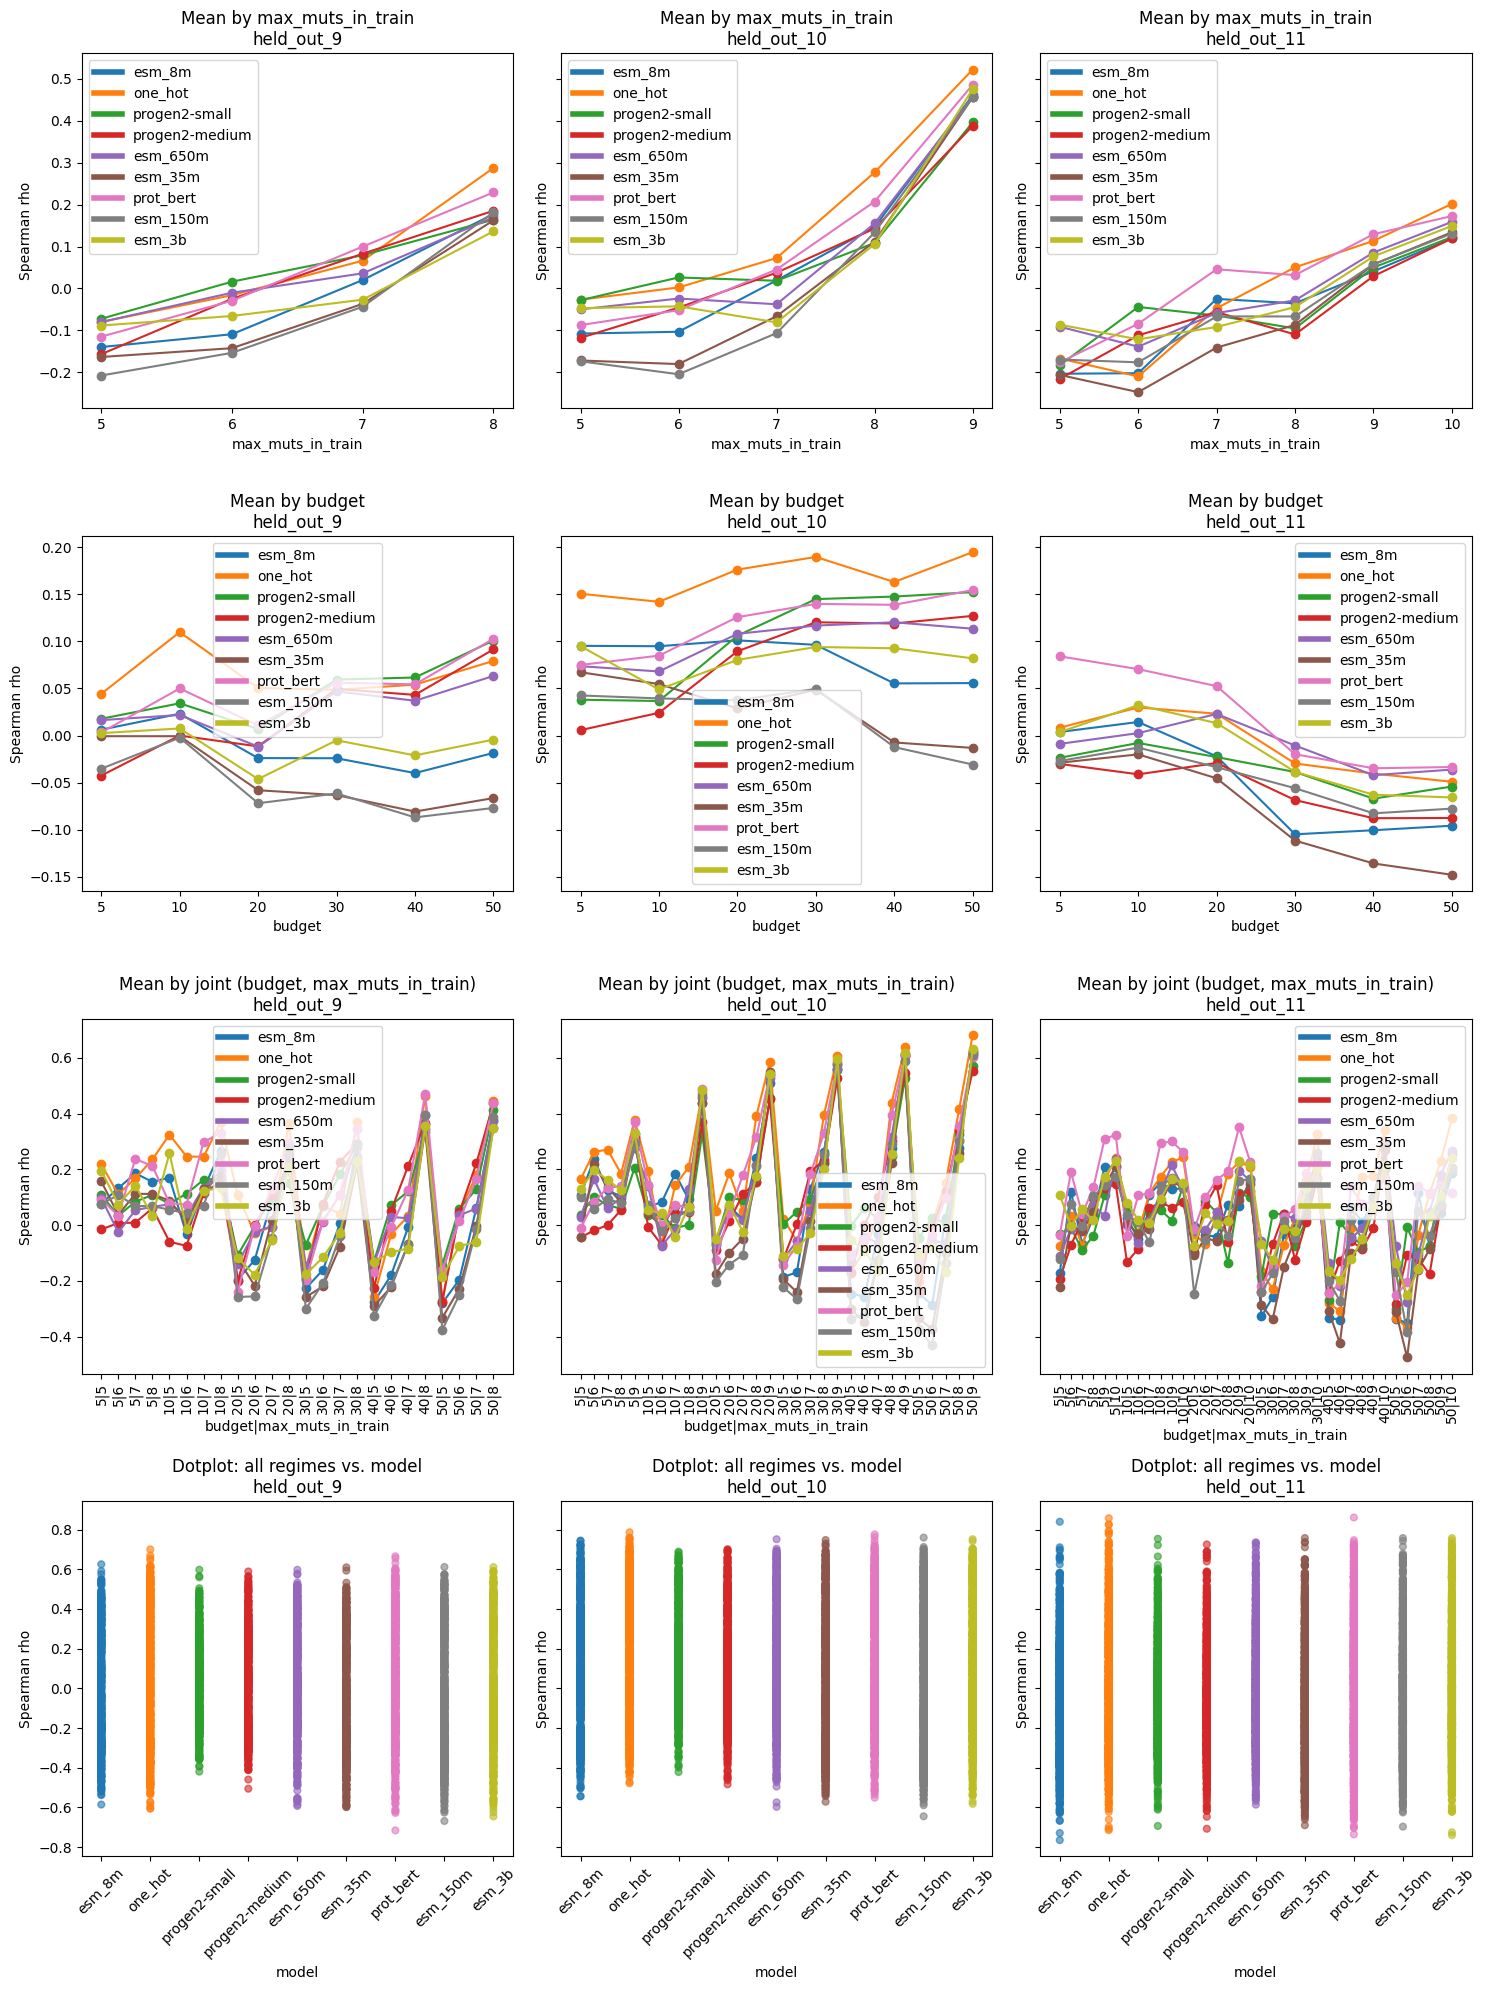

In [ ]:
plot_means = True

fig, axes = plt.subplots(4, 3, figsize=(15, 20), sharey="row")
model_names = ["esm_8m", "one_hot", "progen2-small", "progen2-medium", "esm_650m", "esm_35m", "prot_bert", "esm_150m", "esm_3b"]
colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]

for col, (df_tmp, set_name) in enumerate(zip([df_9, df_10, df_11], ["held_out_9", "held_out_10", "held_out_11"])):
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    width = 0
    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(muts_sorted))]
        data = [df_tmp[(df_tmp["max_muts_in_train"] == m) & (df_tmp["model_name"] == model_name)]["cor_llm"] for m in muts_sorted]
        if plot_means:
            means = [d.mean() if len(d) > 0 else np.nan for d in data]
            axes[0, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[0, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[0, col].set_xticks(range(len(muts_sorted)))
    axes[0, col].set_xticklabels(muts_sorted)
    axes[0, col].set_xlabel("max_muts_in_train")
    axes[0, col].set_ylabel("Spearman rho")
    axes[0, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by max_muts_in_train\n{set_name}")
    axes[0, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    budgets_sorted = sorted(df_tmp["budget"].unique())
    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(budgets_sorted))]
        data = [df_tmp[(df_tmp["budget"] == b) & (df_tmp["model_name"] == model_name)]["cor_llm"] for b in budgets_sorted]
        if plot_means:
            means = [d.mean() if len(d) > 0 else np.nan for d in data]
            axes[1, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[1, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[1, col].set_xticks(range(len(budgets_sorted)))
    axes[1, col].set_xticklabels(budgets_sorted)
    axes[1, col].set_xlabel("budget")
    axes[1, col].set_ylabel("Spearman rho")
    axes[1, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by budget\n{set_name}")
    axes[1, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    joint_groups = (
        df_tmp.groupby(["budget", "max_muts_in_train", "model_name"])["cor_llm"]
        .apply(list)
        .reset_index()
    )
    joint_groups["label"] = joint_groups.apply(
        lambda row: f"{int(row['budget'])}|{int(row['max_muts_in_train'])}", axis=1
    )
    base_labels = sorted(
        {(int(row["budget"]), int(row["max_muts_in_train"])) for _, row in joint_groups.iterrows()},
        key=lambda x: (x[0], x[1])
    )
    boxplot_data = {model_name: [] for model_name in model_names}
    boxplot_labels = []
    for budget, max_muts_in_train in base_labels:
        for model_name in model_names:
            rows = joint_groups[
                (joint_groups["budget"] == budget) &
                (joint_groups["max_muts_in_train"] == max_muts_in_train) &
                (joint_groups["model_name"] == model_name)
            ]
            if not rows.empty:
                boxplot_data[model_name].append(rows.iloc[0]["cor_llm"])
            else:
                boxplot_data[model_name].append([])
        boxplot_labels.append(f"{budget}|{max_muts_in_train}")

    for i, model_name in enumerate(model_names):
        positions = [x + (i - 1) * width for x in range(len(boxplot_labels))]
        data = boxplot_data[model_name]
        if plot_means:
            means = [np.percentile(d, 60) if len(d) > 0 else np.nan for d in data]
            axes[2, col].plot([p for p in positions], means, marker='o', color=colors[i], label=model_name, linestyle="-")
        else:
            axes[2, col].boxplot(
                data, positions=positions, widths=width*0.9, patch_artist=True, boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black')
            )
    axes[2, col].set_xticks(range(len(boxplot_labels)))
    axes[2, col].set_xticklabels(boxplot_labels, rotation=90)
    axes[2, col].set_xlabel("budget|max_muts_in_train")
    axes[2, col].set_ylabel("Spearman rho")
    axes[2, col].set_title(f"{'Mean' if plot_means else 'Boxplot'} by joint (budget, max_muts_in_train)\n{set_name}")
    axes[2, col].legend([plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(len(model_names))], model_names, loc="best")

    dotplot_data = []
    dotplot_models = []
    dotplot_colors = []
    for i, model_name in enumerate(model_names):
        vals = df_tmp[df_tmp["model_name"] == model_name]["cor_llm"]
        if hasattr(vals, "explode"):
            vals = vals.explode()
        dotplot_data.extend(vals.astype(float).values.tolist())
        dotplot_models.extend([model_name]*len(vals))
        dotplot_colors.extend([colors[i]]*len(vals))
    xpos = [model_names.index(m) for m in dotplot_models]
    axes[3, col].scatter(xpos, dotplot_data, color=dotplot_colors, alpha=0.6, s=24)
    axes[3, col].set_xticks(range(len(model_names)))
    axes[3, col].set_xticklabels(model_names, rotation=45)
    axes[3, col].set_xlabel("model")
    axes[3, col].set_ylabel("Spearman rho")
    axes[3, col].set_title(f"Dotplot: all regimes vs. model\n{set_name}")

plt.tight_layout()
plt.show()


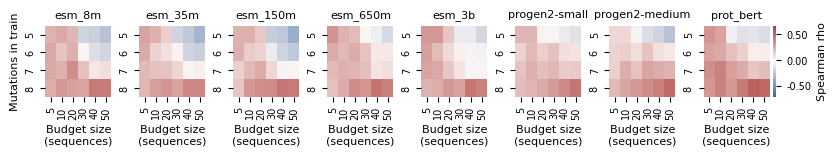

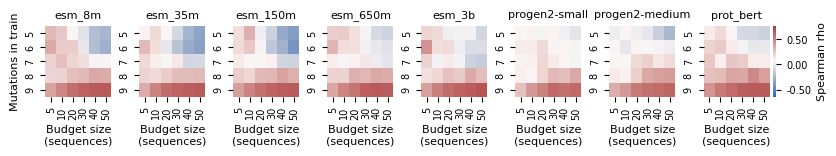

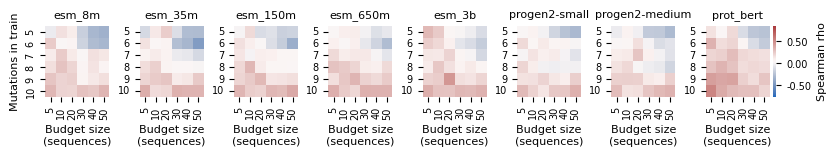

In [ ]:


title_fontsize = 8
label_fontsize = 8
tick_fontsize = 7
legend_fontsize = 7

model_names = ["esm_8m", "esm_35m", "esm_150m", "esm_650m",  "esm_3b",  "progen2-small", "progen2-medium", "prot_bert"]

set_infos = [
    (df_9, "held_out_9"),
    (df_10, "held_out_10"),
    (df_11, "held_out_11"),
]

all_tensors = []
one_hot_tensors = []

for df_tmp, set_name in set_infos:
    held_out_tensor = []
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    all_spearman_values = []
    for model_name in model_names:
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if hasattr(vals, "explode"):
                    vals = vals.explode()
                all_spearman_values.extend(vals.astype(float).values.tolist())
    vmin = np.nanmin(all_spearman_values)
    vmax = np.nanmax(all_spearman_values)

    fig, axes = plt.subplots(1, 8, figsize=(8.25, 1.45), constrained_layout=True)

    for ax, model_name in zip(axes, model_names):
        heatmap_vals = np.full((len(muts_sorted), len(budgets_sorted)), np.nan)
        for i, m in enumerate(muts_sorted):
            for j, b in enumerate(budgets_sorted):
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if len(vals) > 0:
                    try:
                        numeric_vals = vals.astype(float).values
                        value = np.percentile(numeric_vals, 75)
                    except Exception:
                        value = np.nan
                else:
                    value = np.nan
                heatmap_vals[i, j] = value

        if model_name == "one_hot":
            one_hot_tensors.append(heatmap_vals)
        else:
            held_out_tensor.append(heatmap_vals)

        # Create the heatmap and keep the return value (which is the Axes object)
        cbar_show = (ax == axes[-1])
        heatmap = sns.heatmap(
            heatmap_vals,
            annot=False,
            fmt=".2f",
            xticklabels=budgets_sorted,
            yticklabels=muts_sorted,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap="vlag",
            cbar=cbar_show,  # Only show colorbar on last plot
            cbar_kws={"label": "Spearman rho", "shrink": 1.0, "format": "%.2f"} if cbar_show else None,
        )
        # Set colorbar label and tick font size (only for the colorbar instance)
        if cbar_show and heatmap.collections:
            cbar = heatmap.collections[0].colorbar
            cbar.set_label("Spearman rho", fontsize=label_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)
        ax.set_title(model_name, fontsize=title_fontsize)
        ax.set_xlabel("Budget size\n(sequences)", fontsize=label_fontsize)
        ax.set_ylabel("Mutations in train" if ax == axes[0] else "", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

    held_out_tensor = np.stack(held_out_tensor, axis=0)
    all_tensors.append(held_out_tensor)

    #fig.suptitle(f"Spearman rho heatmap for '{set_name}'", fontsize=title_fontsize)
    plt.show()
    output_dir = "./figures/figure_2"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "nmt_heatmap_%s.svg" % set_name), bbox_inches='tight')



In [ ]:
title_fontsize = 8
label_fontsize = 8
tick_fontsize = 7
legend_fontsize = 7

model_names = ["ohe", "esm_35m"]

set_infos = [
    (df_9, "held_out_9"),
    (df_10, "held_out_10"),
    (df_11, "held_out_11"),
]

all_tensors = []
one_hot_tensors = []

for df_tmp, set_name in set_infos:
    held_out_tensor = []
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    all_spearman_values = []
    for model_name in model_names:
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if hasattr(vals, "explode"):
                    vals = vals.explode()
                all_spearman_values.extend(vals.astype(float).values.tolist())
    vmin = np.nanmin(all_spearman_values)
    vmax = np.nanmax(all_spearman_values)

    fig, axes = plt.subplots(1, 8, figsize=(3, 1.45), constrained_layout=True)

    for ax, model_name in zip(axes, model_names):
        heatmap_vals = np.full((len(muts_sorted), len(budgets_sorted)), np.nan)
        for i, m in enumerate(muts_sorted):
            for j, b in enumerate(budgets_sorted):
                vals = df_tmp[
                    (df_tmp["budget"] == b)
                    & (df_tmp["max_muts_in_train"] == m)
                    & (df_tmp["model_name"] == model_name)
                ]["cor_llm"]
                if len(vals) > 0:
                    try:
                        numeric_vals = vals.astype(float).values
                        value = np.percentile(numeric_vals, 75)
                    except Exception:
                        value = np.nan
                else:
                    value = np.nan 
                heatmap_vals[i, j] = value

        if model_name == "one_hot":
            one_hot_tensors.append(heatmap_vals)
        else:
            held_out_tensor.append(heatmap_vals)

        # Create the heatmap and keep the return value (which is the Axes object)
        cbar_show = (ax == axes[-1])
        heatmap = sns.heatmap(
            heatmap_vals,
            annot=False,
            fmt=".2f",
            xticklabels=budgets_sorted,
            yticklabels=muts_sorted,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap="vlag",
            cbar=cbar_show,  # Only show colorbar on last plot
            cbar_kws={"label": "Spearman rho", "shrink": 1.0, "format": "%.2f"} if cbar_show else None,
        )
        # Set colorbar label and tick font size (only for the colorbar instance)
        if cbar_show and heatmap.collections:
            cbar = heatmap.collections[0].colorbar
            cbar.set_label("Spearman rho", fontsize=label_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)
        ax.set_title(model_name, fontsize=title_fontsize)
        ax.set_xlabel("Budget size\n(sequences)", fontsize=label_fontsize)
        ax.set_ylabel("Mutations in train" if ax == axes[0] else "", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

    held_out_tensor = np.stack(held_out_tensor, axis=0)
    all_tensors.append(held_out_tensor)

    #fig.suptitle(f"Spearman rho heatmap for '{set_name}'", fontsize=title_fontsize)
    plt.show()
    output_dir = "./figures/figure_3"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "nmt_heatmap_ohe_llm%s.svg" % set_name), bbox_inches='tight')



NameError: name 'df_9' is not defined

In [13]:
def mean_without_nan(statistics_matrix):
    mu_vec = np.apply_along_axis(lambda col: np.nanmean(col), axis=0, arr=statistics_matrix)
    return mu_vec

def calculate_ss_for_df_and_factors(df, 
    factors = ["model_name", "train_mutations"], 
    variables_to_calculate = ["roc", "top_100_pct", "precision", "f1", "accuracy", "recall"]
):
    results = []
    ss_all = []

    for var in variables_to_calculate:
        SS_ALL = (df[var] - df[var].mean()) ** 2
        for factor in factors:
            groups_in_factor = df[factor].unique()
            for group in groups_in_factor:
                group_df = df[df[factor] == group]
                SS = (group_df[var] - group_df[var].mean()) ** 2
                results.append({
                    'factor_name': factor,
                    'SS': SS.sum(),
                    'group': group,
                    'var': var
                })

        ss_all.append({"var": var, "SS": SS_ALL.sum()})

    results_df = pd.DataFrame(results)
    ss_all = pd.DataFrame(ss_all)

    return ss_all, results_df





In [14]:
no_ohe_df = df[df["model_name"] != "one_hot"]
held_out_sets = no_ohe_df["set_name"].unique()
models = no_ohe_df["model_name"].unique()

factors = ["model_name", "budget", "max_muts_in_train"]

vars_and_func = {"mean_cor_llm" : lambda v: vals.mean(),
                #  "std_cor_llm" : lambda v: vals.std(),
                # "median_cor_llm" : lambda v: vals.median(),
                #  "min_cor_llm" : lambda v: vals.min(),
                #  "max_cor_llm" : lambda v: vals.max(),
                 "75_cor_llm" : lambda v: np.percentile(vals, 75)}#,
                #  "25_cor_llm" : lambda v: np.percentile(vals, 25),
                #"85_cor_llm" : lambda v: np.percentile(vals, 85),
                #  "15_cor_llm" : lambda v: np.percentile(vals, 15),
                #"95_cor_llm" : lambda v: np.percentile(vals, 95),
                #"05_cor_llm" : lambda v: np.percentile(vals, 5)}


discretized_parameter_scale = {"esm_35m": "0_100",
                                "esm_8m": "0_100",
                                "esm_150m": "100_500",
                                "esm_650m": "500_1000",
                                "esm_3b": "500_1000",
                                "progen2-small": "100_500",
                                "progen2-medium": "500_1000",
                                "prot_bert": "100_500"}


vars = list(vars_and_func.keys())
results = []

for held_out_set in held_out_sets:
    
    df_tmp = df[df["set_name"] == held_out_set]
    muts_sorted = sorted(df_tmp["max_muts_in_train"].unique())
    budgets_sorted = sorted(df_tmp["budget"].unique())

    for model_name in models:
        df_tmp_model = df_tmp[df_tmp["model_name"] == model_name]
        
        for b in budgets_sorted:
            for m in muts_sorted:
                vals = df_tmp_model[(df_tmp_model["budget"] == b) & (
                                     df_tmp_model["max_muts_in_train"] == m)]["cor_llm"]
                                     
                metadata = {"model_name": model_name, 
                            "budget": b, 
                            "max_muts_in_train": m, 
                            #"muts_budget": f"m_{m}_b_{b}",
                            #"muts_model": f"m_{m}_mdl_{model_name}",
                            #"budget_model": f"b_{b}_mdl_{model_name}",
                            "set": held_out_set,
                            "scale": discretized_parameter_scale[model_name]}

                statistics = {var: vars_and_func[var](vals) for var in vars}
                results.append({**metadata, **statistics})


                    



In [15]:
rsdf =  pd.DataFrame(results)


In [16]:
var_explained_factor_results = []

extended_factors = np.concatenate([factors, ["scale"]])#, "muts_budget", "muts_model", "budget_model"]])
for held_out_set in held_out_sets:

    ss_all, results_df = calculate_ss_for_df_and_factors(rsdf[rsdf["set"] == held_out_set], 
                                                         factors=extended_factors, 
                                                         variables_to_calculate=vars)

    for var in vars:
        for factor in extended_factors:
            ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
            total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
                

            var_explained_factor_results.append({"var": var, 
                                                "factor": factor, 
                                                "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})

var_explained_factor_df = pd.DataFrame(var_explained_factor_results)

In [26]:
xlabel_dict = {
    'model_name': 'Model',
    'scale': 'Model parameters',
    'max_muts_in_train': 'Mutations in train',
    'budget': 'Budget size'
}

title_fontsize = 10
label_fontsize = 10
tick_fontsize = 10
legend_fontsize = 10

for var in var_explained_factor_df['var'].unique():
    plot_df = var_explained_factor_df[var_explained_factor_df['var'] == var]
    factors = plot_df['factor'].unique()
    means = []
    for f in extended_factors:
        vals = plot_df[plot_df['factor'] == f]['var_explained']
        means.append(vals.mean())

    means = np.array(means)
    leftover = 1.0 - means
    leftover = np.clip(leftover, 0, 1)  # ensure no negative bar

    x = np.arange(len(extended_factors))
    fig, ax = plt.subplots(figsize=(4, 3))

    # The main (colored) bar
    bar1 = ax.bar(x, means, color="skyblue", edgecolor="k", label='Explained')
    # The leftover (gray) bar, stacked above
    bar2 = ax.bar(x, leftover, bottom=means, color="lightgray", edgecolor="k", label='Unexplained')

    xlabels = [xlabel_dict[f] for f in extended_factors]
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
    ax.set_ylabel('Variance explained', fontsize=label_fontsize)
    ax.set_xticks(x)
    ax.set_ylim(0, 1)

    # Optionally, legend:
    # ax.legend(fontsize=legend_fontsize)

    plt.tight_layout()
    output_dir = "./figures/figure_2"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "var_explained_nmt_%s.svg" % var), bbox_inches='tight')
    #plt.show()
    plt.close()


/tmp/ipykernel_1919096/2345190198.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
/tmp/ipykernel_1919096/2345190198.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)


In [18]:
models

array(['esm_8m', 'esm_35m', 'esm_150m', 'esm_650m', 'esm_3b',
       'progen2-small', 'progen2-medium', 'prot_bert'], dtype=object)

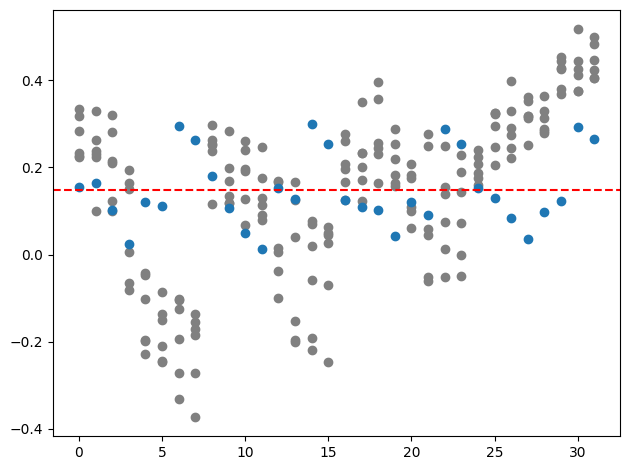

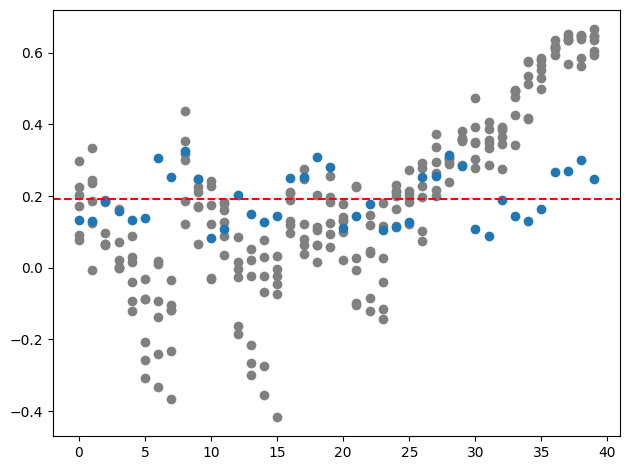

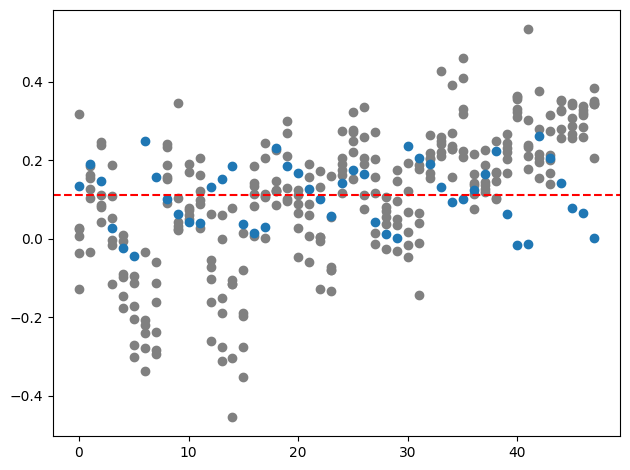

In [19]:
N_models = 6
all_dfs = []

for testing_set in range(0,3):
    by_model = all_tensors[testing_set].mean(axis=1).mean(axis=1)
    by_budget = all_tensors[testing_set].mean(axis=0).mean(axis=0)
    by_muts = all_tensors[testing_set].mean(axis=0).mean(axis=1)
    
    by_muts_and_budget = all_tensors[testing_set].reshape((N_models,-1)).mean(axis=0)
    mean_all = all_tensors[testing_set].mean()

    x_labels = [
        f'budget{b}_muts{m}'
        for b in range(all_tensors[testing_set].shape[1])
        for m in range(all_tensors[testing_set].shape[2])
        for mod in range(all_tensors[testing_set].shape[0])
    ]

    x_values = [[i] * N_models for i in range(by_muts_and_budget.shape[0])]
    x_values = [item for sublist in x_values for item in sublist]

    N_M, N_MT, N_B = all_tensors[testing_set].shape

    by_model_and_budget_2 = np.stack([all_tensors[testing_set][:,i,:].reshape(-1) for i in range(N_MT)], axis=0).mean(axis=0)
    by_model_and_mut_2 = np.stack([all_tensors[testing_set][:,:,i].reshape(-1) for i in range(N_B)], axis=0).mean(axis=0)
    by_muts_and_budgets_2 = np.stack([all_tensors[testing_set][i,:,:].reshape(-1) for i in range(N_M)], axis=0).mean(axis=0)


    tmp = []
    for i in range(N_MT):
        for j in range(N_B):
            tmp.append(all_tensors[testing_set][:,i,j])

    values = np.concatenate(tmp, axis=0)

    plt.figure()
    plt.scatter(x=x_values, y=values, color="gray")
    plt.scatter(x=range(0,by_muts_and_budget.shape[0]), y=by_muts_and_budget)
    #plt.xticks(range(len(values)), x_labels, rotation=90, fontsize=8)
    plt.axhline(y=values.mean(), color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

    


    SS_ALL = (mean_all - all_tensors[testing_set].reshape((-1))) ** 2
    SS_BY_MODEL = (mean_all - by_model) ** 2
    SS_BY_BUDGET = (mean_all - by_budget) ** 2
    SS_BY_MUTS = (mean_all - by_muts) ** 2
    SS_BY_MUTS_AND_BUDGET = (mean_all - by_muts_and_budget) ** 2

    SS_BY_model_and_budget_2 = (mean_all - by_model_and_budget_2) ** 2
    SS_BY_model_and_mut_2 = (mean_all - by_model_and_mut_2) ** 2
    SS_BY_muts_and_budgets_2 = (mean_all - by_muts_and_budgets_2) ** 2

    #SS_ALL = np.array([1])
    res = {"set": testing_set,
           "SS_ALL" : sum(SS_ALL),
           "SS_BY_MODEL" : sum(SS_BY_MODEL),
           "SS_BY_BUDGET" : sum(SS_BY_BUDGET),
           "SS_BY_MUTS" : sum(SS_BY_MUTS),
           "SS_BY_MUTS_AND_BUDGET" : sum(SS_BY_MUTS_AND_BUDGET),
           "SS_BY_model_and_budget_2": sum(SS_BY_model_and_budget_2),
           "SS_BY_model_and_mut_2": sum(SS_BY_model_and_mut_2),
           "SS_BY_muts_and_budgets_2": sum(SS_BY_muts_and_budgets_2)}

    tmp_df = pd.DataFrame([res])

    all_dfs.append(tmp_df)
    
    
    




all_dfs = pd.concat(all_dfs)


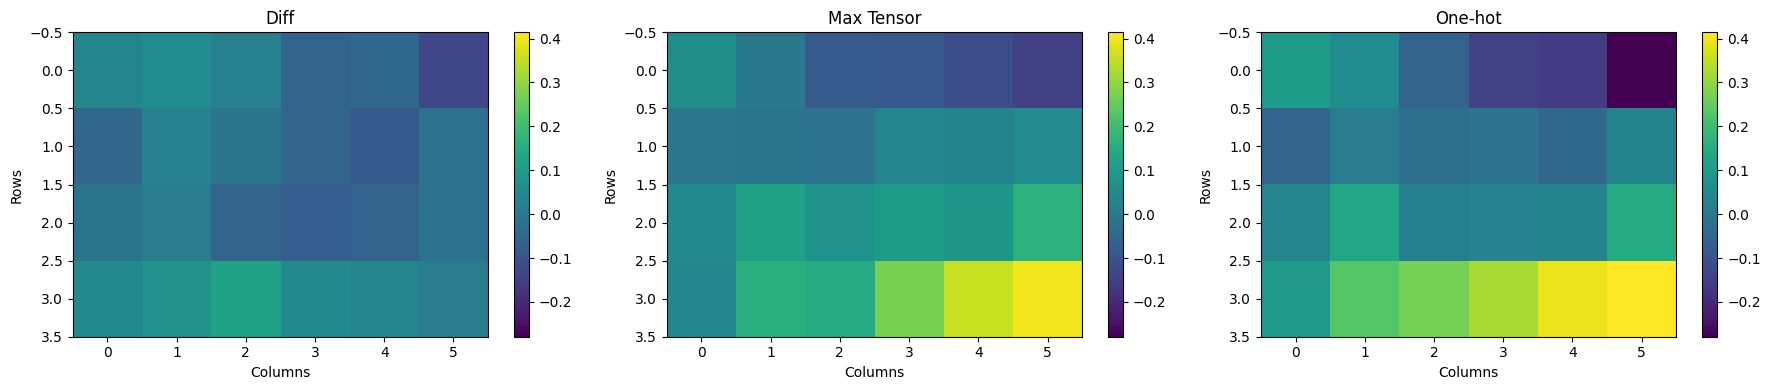

In [14]:

testing_set = 0
vmin = min(
    (one_hot_tensors[testing_set] - all_tensors[testing_set].max(axis=0)).min(),
    all_tensors[testing_set].max(axis=0).min(),
    one_hot_tensors[testing_set].min(),
)
vmax = max(
    (one_hot_tensors[testing_set] - all_tensors[testing_set].max(axis=0)).max(),
    all_tensors[testing_set].max(axis=0).max(),
    one_hot_tensors[testing_set].max(),
)
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
im0 = axs[0].imshow(one_hot_tensors[testing_set] - all_tensors[testing_set].max(axis=0), aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title("Diff")
im1 = axs[1].imshow(all_tensors[testing_set].max(axis=0), aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("Max Tensor")
im2 = axs[2].imshow(one_hot_tensors[testing_set], aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axs[2].set_title("One-hot")
for ax in axs:
    ax.set_xlabel("Columns")
    ax.set_ylabel("Rows")
    fig.colorbar(ax.images[0], ax=ax)
plt.tight_layout()
plt.show()


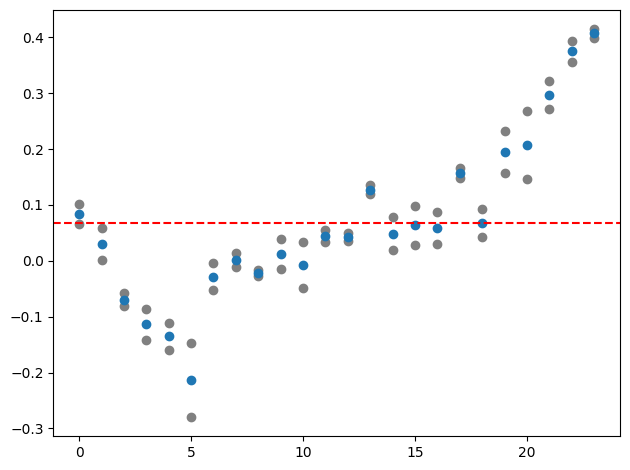

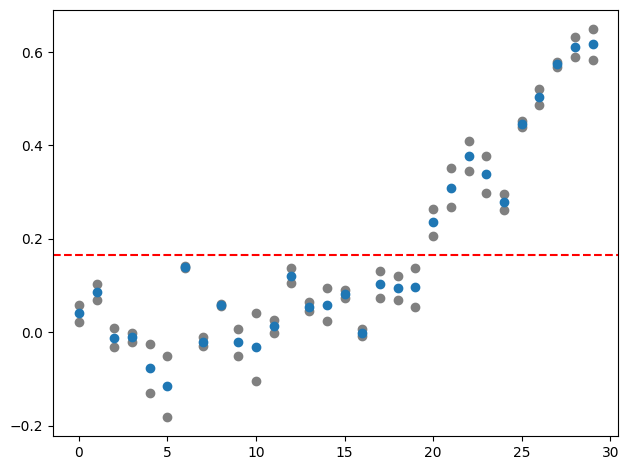

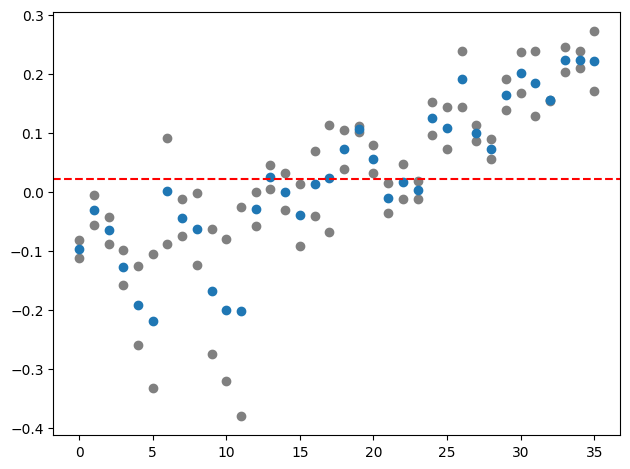

In [15]:



ohe_llm = []

for testing_set in range(0,3):

    working_tensor = np.stack([one_hot_tensors[testing_set],  all_tensors[testing_set].max(axis=0)], axis=0)
    by_model = working_tensor.mean(axis=1).mean(axis=1)
    by_budget = working_tensor.mean(axis=0).mean(axis=0)
    by_muts = working_tensor.mean(axis=0).mean(axis=1)
    
    by_muts_and_budget = working_tensor.reshape((2,-1)).mean(axis=0)
    mean_all = working_tensor.mean()

    x_labels = [
        f'budget{b}_muts{m}'
        for b in range(working_tensor.shape[1])
        for m in range(working_tensor.shape[2])
        for mod in range(working_tensor.shape[0])
    ]

    x_values = [[i] * 2 for i in range(by_muts_and_budget.shape[0])]
    x_values = [item for sublist in x_values for item in sublist]

    N_M, N_MT, N_B = working_tensor.shape

    by_model_and_budget_2 = np.stack([working_tensor[:,i,:].reshape(-1) for i in range(N_MT)], axis=0).mean(axis=0)
    by_model_and_mut_2 = np.stack([working_tensor[:,:,i].reshape(-1) for i in range(N_B)], axis=0).mean(axis=0)
    by_muts_and_budgets_2 = np.stack([working_tensor[i,:,:].reshape(-1) for i in range(N_M)], axis=0).mean(axis=0)


    tmp = []
    for i in range(N_MT):
        for j in range(N_B):
            tmp.append(working_tensor[:,i,j])

    values = np.concatenate(tmp, axis=0)

    plt.figure()
    plt.scatter(x=x_values, y=values, color="gray")
    plt.scatter(x=range(0,by_muts_and_budget.shape[0]), y=by_muts_and_budget)
    #plt.xticks(range(len(values)), x_labels, rotation=90, fontsize=8)
    plt.axhline(y=values.mean(), color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

    


    SS_ALL = (mean_all - working_tensor.reshape((-1))) ** 2
    SS_BY_MODEL = (mean_all - by_model) ** 2
    SS_BY_BUDGET = (mean_all - by_budget) ** 2
    SS_BY_MUTS = (mean_all - by_muts) ** 2
    SS_BY_MUTS_AND_BUDGET = (mean_all - by_muts_and_budget) ** 2

    SS_BY_model_and_budget_2 = (mean_all - by_model_and_budget_2) ** 2
    SS_BY_model_and_mut_2 = (mean_all - by_model_and_mut_2) ** 2
    SS_BY_muts_and_budgets_2 = (mean_all - by_muts_and_budgets_2) ** 2

    #SS_ALL = np.array([1])
    res = {"set": testing_set,
           "SS_ALL" : sum(SS_ALL),
           "SS_BY_MODEL" : sum(SS_BY_MODEL),
           "SS_BY_BUDGET" : sum(SS_BY_BUDGET),
           "SS_BY_MUTS" : sum(SS_BY_MUTS),
           "SS_BY_MUTS_AND_BUDGET" : sum(SS_BY_MUTS_AND_BUDGET),
           "SS_BY_model_and_budget_2": sum(SS_BY_model_and_budget_2),
           "SS_BY_model_and_mut_2": sum(SS_BY_model_and_mut_2),
           "SS_BY_muts_and_budgets_2": sum(SS_BY_muts_and_budgets_2)}

    tmp_df = pd.DataFrame([res])

    ohe_llm.append(tmp_df)
    
    
    




ohe_llm = pd.concat(ohe_llm)


In [16]:
ohe_llm["SS_BY_MUTS_AND_BUDGET"] / ohe_llm["SS_ALL"]

0    0.481196
0    0.489982
0    0.414390
dtype: float64

In [16]:
print(all_dfs["SS_BY_MUTS_AND_BUDGET"] / all_dfs["SS_ALL"])
print(all_dfs["SS_BY_MODEL"] / all_dfs["SS_ALL"])
print(all_dfs["SS_BY_BUDGET"] / all_dfs["SS_ALL"])
print(all_dfs["SS_BY_MUTS"] / all_dfs["SS_ALL"])
all_dfs["SS_BY_MUTS_AND_BUDGET"] / all_dfs["SS_ALL"]



0    0.141443
0    0.152984
0    0.136198
dtype: float64
0    0.003141
0    0.000834
0    0.001450
dtype: float64
0    0.000432
0    0.000090
0    0.001788
dtype: float64
0    0.016568
0    0.021058
0    0.017383
dtype: float64


0    0.141443
0    0.152984
0    0.136198
dtype: float64

In [17]:
all_dfs

,set,SS_ALL,SS_BY_MODEL,SS_BY_BUDGET,SS_BY_MUTS,SS_BY_MUTS_AND_BUDGET,SS_BY_model_and_budget_2,SS_BY_model_and_mut_2,SS_BY_muts_and_budgets_2
0,0,3.325934,0.010448,0.001437,0.055106,0.470431,0.092326,0.390528,0.470431
0,1,10.185153,0.008499,0.000919,0.214481,1.558165,0.087246,1.374104,1.558165
0,2,4.230987,0.006134,0.007565,0.073547,0.576254,0.092922,0.515758,0.576254


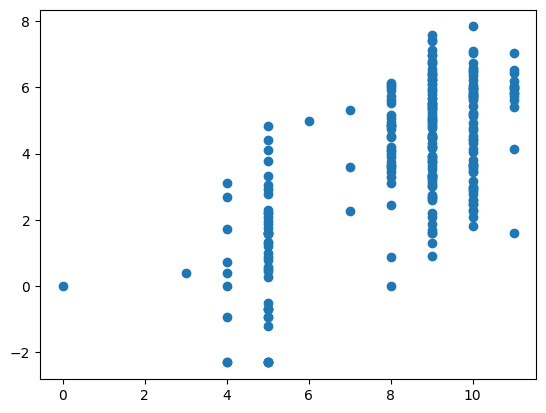

In [3]:
plt.scatter(x=(df_nmt["num_muts"]), y=np.log(df_nmt["activity"]))